<a href="https://colab.research.google.com/github/Bubukisapisa/ML_education/blob/main/HW_2_5_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [2]:
pip install statsforecast

In [3]:
pip install darts

In [4]:
!pip install pytorch_lightning

In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

In [6]:
from darts import TimeSeries
from darts.models import NaiveSeasonal
from darts.models import NaiveDrift
from darts.models import ExponentialSmoothing, ARIMA, AutoARIMA, Theta

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv('drive/MyDrive/ML for people/train.csv.zip')

In [9]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df = df.set_index('date')

In [12]:
df.head()

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10


In [13]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [14]:
results = []

for pid, group in df.groupby('item'):
  m = group['sales'].mean()
  se = stats.sem(group['sales'])
  margin = se * stats.t.ppf(0.975, df=len(group) - 1)
  results.append({'item': pid, 'mean': m, 'margin': margin})

ci_df = pd.DataFrame(results).sort_values('mean', ascending=False)

In [15]:
ci_df.set_index('item').head()

,mean,margin
item,,
15,88.030778,0.428238
28,87.881325,0.427932
13,84.316594,0.410660
18,84.275794,0.412394
25,80.686418,0.395107


Виглядає так що величина довірчих інтервалів дуже мала і нічого в результаті не показуватиме.

In [16]:
order = (
    df.groupby("item")["sales"]
    .median()
    .sort_values(ascending=False).index.to_list()
)

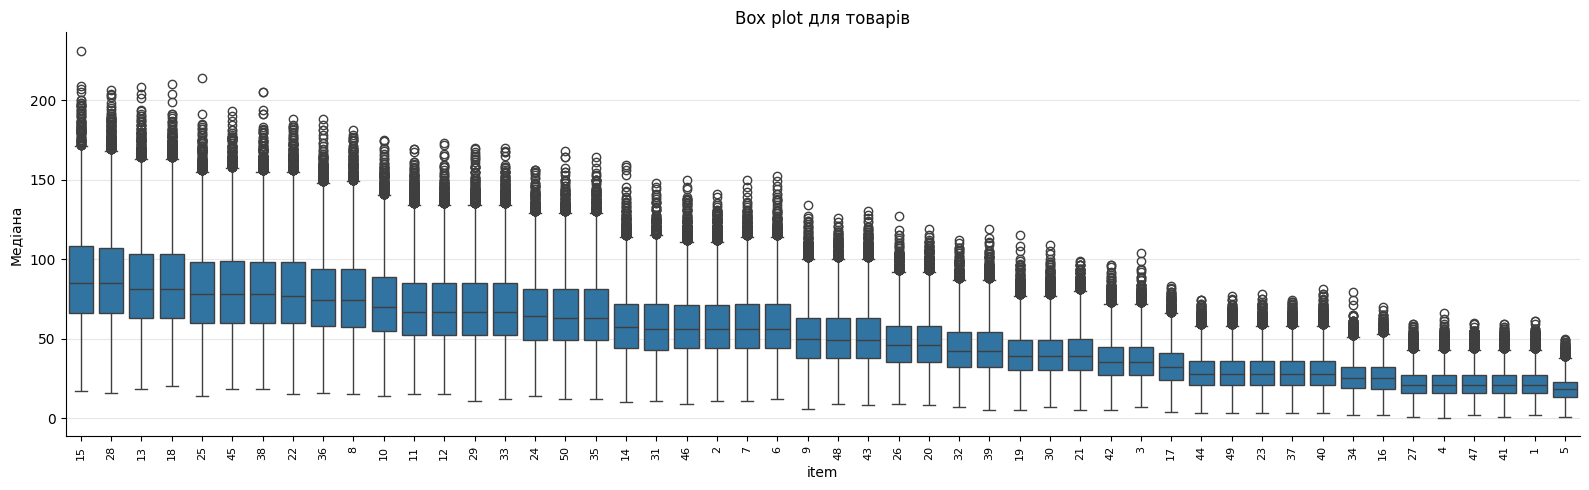

In [17]:
fig, ax = plt.subplots(figsize=(16, 5))

x = np.arange(len(ci_df))

# ax.bar(x, ci_df["mean"], color="#3B82F6", alpha=0.8, zorder=2)
# ax.errorbar(x, ci_df["mean"], yerr=ci_df["margin"],
#             fmt="none", color="#1E3A5F", capsize=3, linewidth=1.2, zorder=3)
sns.boxplot(x='item', y='sales', data=df, order=order)

ax.set_xticks(x)
ax.set_xticklabels([f"{p}" for p in ci_df["item"]], rotation=90, fontsize=8)
ax.set_ylabel("Медіана")
ax.set_title("Box plot для товарів")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

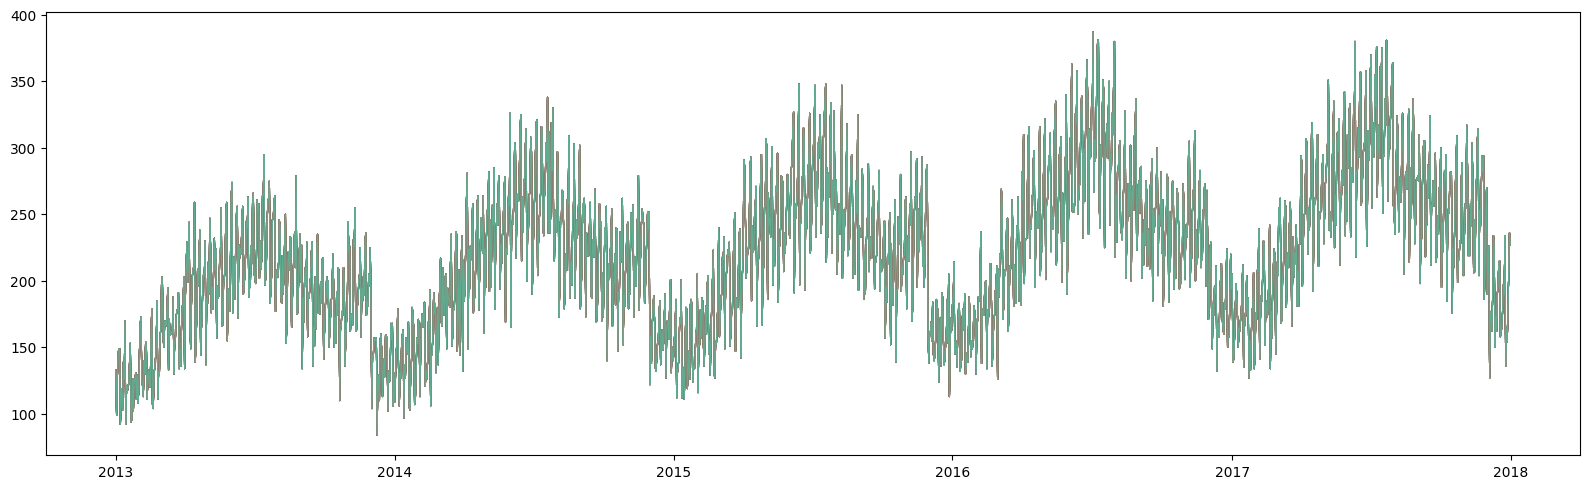

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10


In [18]:
fig, ax = plt.subplots(figsize=(16, 5))

for item in df['item'].unique():
  data = df[df['item'] == 1].groupby('date').sum('sales').reset_index()\
        .sort_values('date')
  ax.plot(data['date'], data['sales'], linewidth = 0.8, alpha=0.5)

plt.tight_layout()
plt.show()
df.head()

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

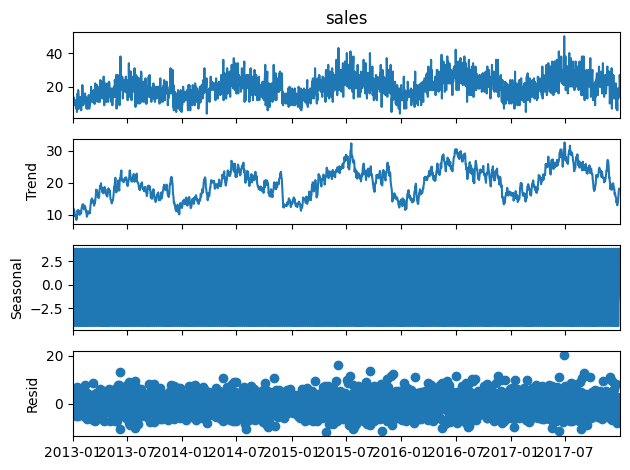

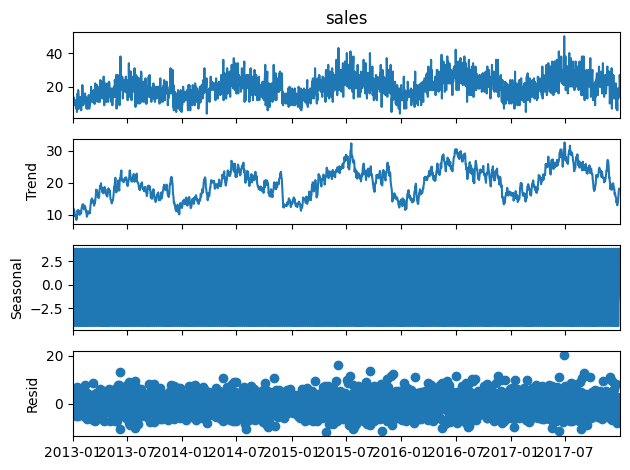

In [19]:
df_it1_st1 = df[(df['item']==1) & (df['store']==1)]
decomposition_plot = seasonal_decompose(df_it1_st1['sales'],
                                              model='additive')
decomposition_plot.plot()

####Проміжний висновок
Дані зовсім нефнофрмативні - тренд виглядає як сезонність, сезонність взагалі неінформативна, залишків багато

In [20]:
df_orig = df.copy()
df_it1_st1 = df_orig[(df_orig['item']==1) & (df_orig['store']==1)]

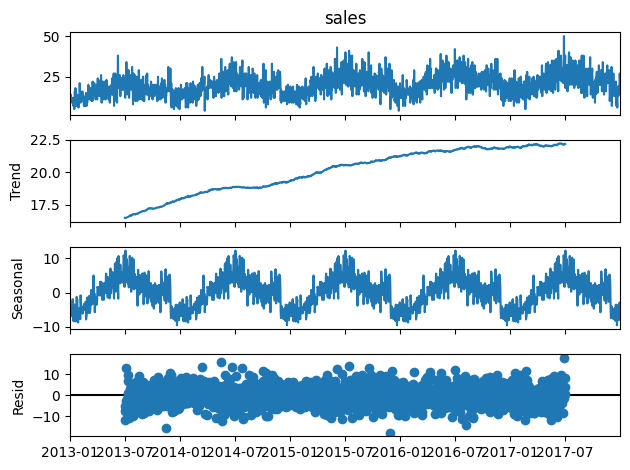

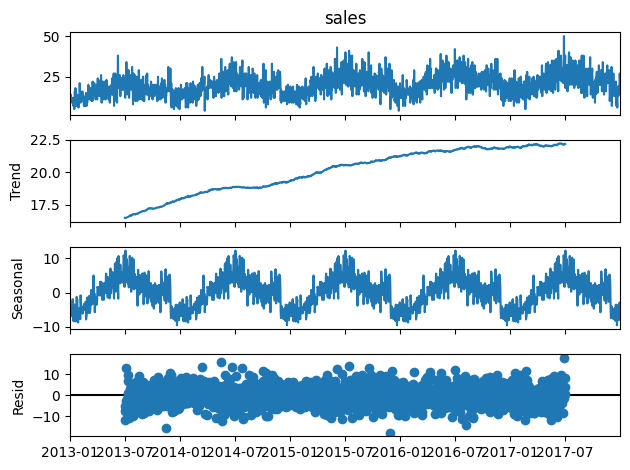

In [21]:
decomposition_plot = seasonal_decompose(df_it1_st1['sales'],period=365,
                                              model='additive')
decomposition_plot.plot()

#### Проміжний висновок
Коли вказав період дані стали значно інформативніші - є чітки висхідний тренд, добре видно річну сезонність, залишки в межах -10 і +10
Величини залишків мені не до вподоби - діапазон -10 та 10 при денних показниках в 10-50, можливо можна виділити ще вплив факторів

In [22]:
df_it1_st1_w = pd.DataFrame(df_it1_st1.reset_index().groupby(pd.Grouper(key='date', freq='W'))['sales'].sum())

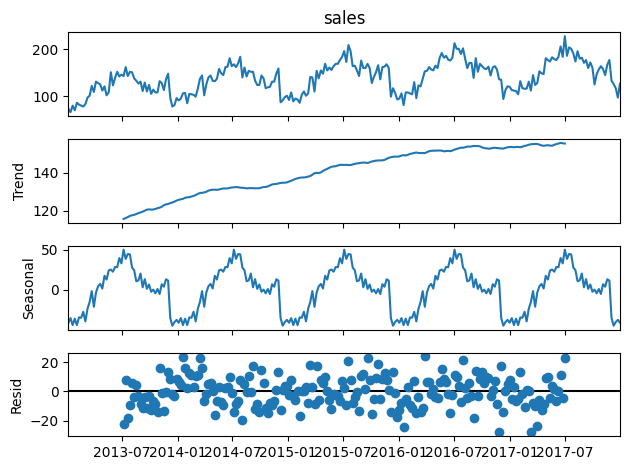

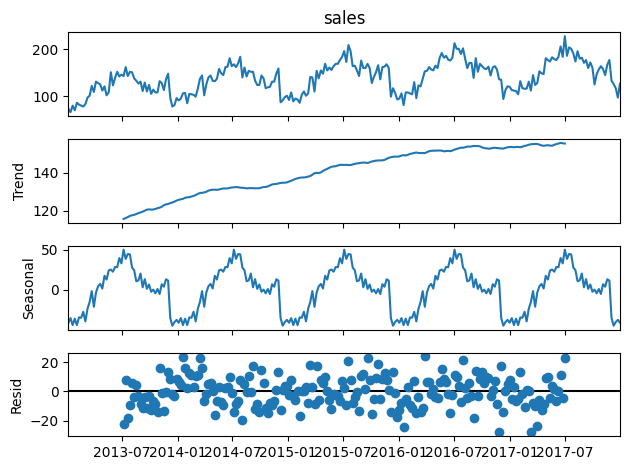

In [23]:
decomposition_plot = seasonal_decompose(df_it1_st1_w['sales'],
                                              model='additive')
decomposition_plot.plot()

#### Проміжний висновок
Щотижневе групування даних дає на мою думку навіть кращу картинку - дані більш читабельні масштаб залишків видається менш суттєвим

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [24]:
series = TimeSeries.from_dataframe(df_it1_st1, value_cols='sales')

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

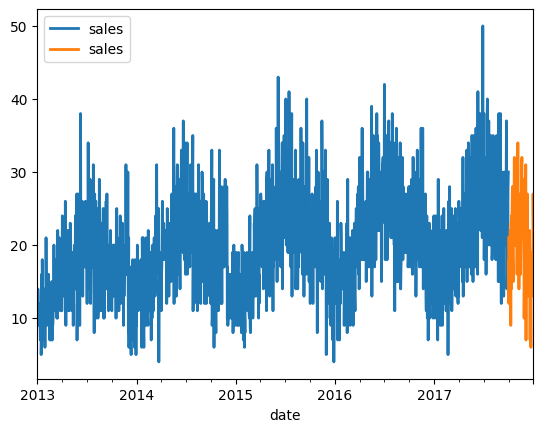

In [25]:
train, val = series.split_before(pd.Timestamp('2017-10-01'))
train.plot()
val.plot()

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

In [26]:
print(len(series))

1826


<Figure size 1000x600 with 0 Axes>

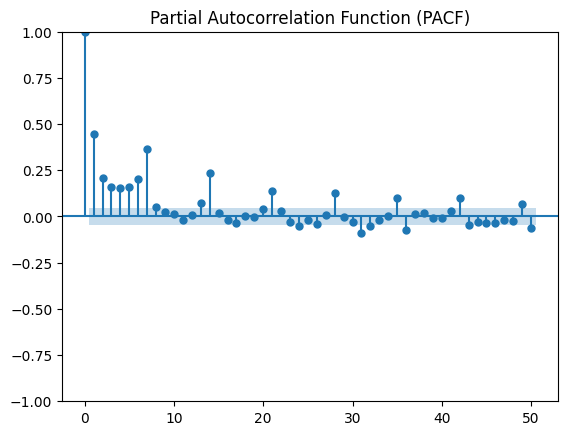

In [27]:
from statsmodels.graphics.tsaplots import plot_pacf
# Візуалізація часткової автокореляційної функції (PACF)
plt.figure(figsize=(10, 6))
plot_pacf(df_it1_st1['sales'], lags=50, method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [28]:
from darts.utils.statistics import check_seasonality

for m in range(2, 50):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05, max_lag=50)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.
There is seasonality of order 28.
There is seasonality of order 35.
There is seasonality of order 42.
There is seasonality of order 49.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

ПОМИЛКА: 47.43446787496835%


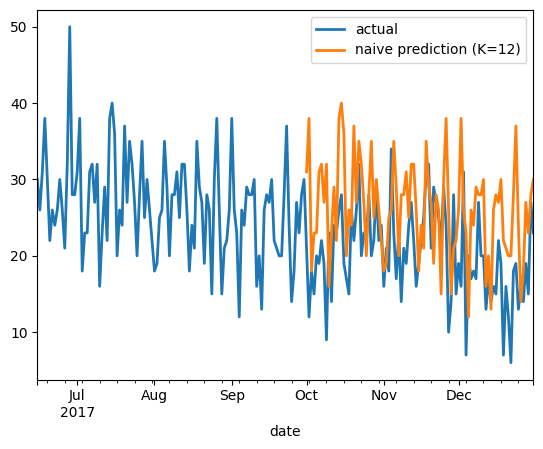

In [59]:
seasonal_model = NaiveSeasonal(K=len(val))
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(len(val))

series[-200:].plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=12)")
print(f'ПОМИЛКА: {mape(val, seasonal_forecast)}%')

ПОМИЛКА: 49.31174337366259%


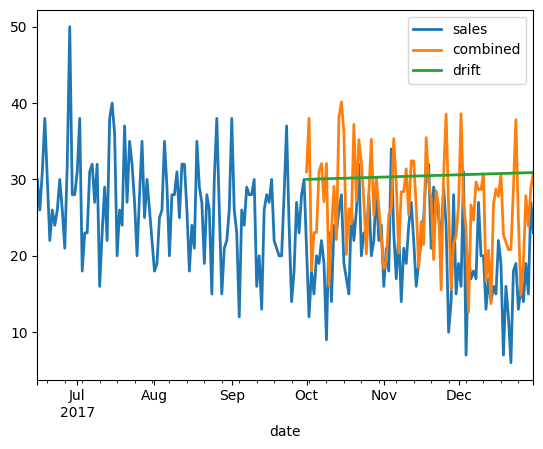

In [58]:
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(len(val))

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

series[-200:].plot()
combined_forecast.plot(label="combined")
drift_forecast.plot(label="drift")
print(f'ПОМИЛКА: {mape(val, combined_forecast)}%')

Модель NaiveSeasonal показує дуже велику помилку, задає вищі значення в середньому ніж фактично є. NaiveDrift на диво погіршив кінцевий прогноз.

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [31]:
from darts.metrics import mape

print(
    f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(val, combined_forecast):.2f}%."
)

Mean absolute percentage error for the combined naive drift + seasonal: 49.31%.


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [32]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler

In [33]:
def enrich_with_date_features(df):
  # Feature Extraction
  df["dayofweek"] = df['date'].dt.dayofweek
  df["quarter"] = df['date'].dt.quarter
  df["month"] = df['date'].dt.month
  df["year"] = df['date'].dt.year
  df["dayofyear"] = df['date'].dt.dayofyear
  df["sin_day"] = np.sin(df["dayofyear"])
  df["cos_day"] = np.cos(df["dayofyear"])
  # df["dayofmonth"] = df['Month'].dt.day
  return df

# Додавання ознак дати
train_transformed = enrich_with_date_features(train.to_dataframe().reset_index())
val_transformed = enrich_with_date_features(val.to_dataframe().reset_index())

# Масштабування даних
scaler = Scaler()
train_transformed = scaler.fit_transform(train)
test_transformed = scaler.transform(val)

# Побудова моделі XGBoost
model = XGBModel(
    lags=len(val),
    output_chunk_length=len(val),
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# Тренування моделі
model.fit(train_transformed)
pred = model.predict(6)
pred.values()

array([[0.5279832 ],
       [0.3218317 ],
       [0.38474685],
       [0.41331697],
       [0.4167982 ],
       [0.4784698 ]], dtype=float32)

In [34]:
scaler.inverse_transform(pred)

,sales
date,
2017-10-01,28.287226
2017-10-02,18.804258
2017-10-03,21.698355
2017-10-04,23.012579
2017-10-05,23.172718
2017-10-06,26.009609


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


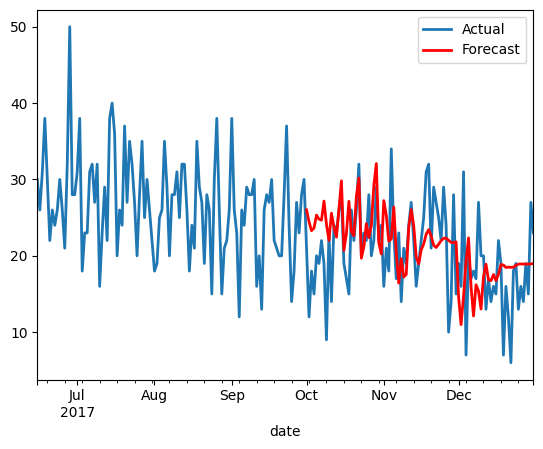

ПОМИЛКА: 29.927808425451566%


In [53]:
forecast = scaler.inverse_transform(model.predict(len(val)))
series[-200:].plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()
print(f'ПОМИЛКА: {mape(val, forecast)}%')

Хоча помилка зменшилась майже на 10 відсоткових пунктів але і ця модель не так добре справляється з прогнозомм як хотілося б, 29.9% - велика помилка

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [36]:
def plot_results(series, forecast):
  # Візуалізація результатів
  series.plot(label='Actual')
  forecast.plot(label='Forecast', color='red')
  plt.legend()
  plt.show()

def fit_and_plot(model, series, train, val):
  model.fit(train)
  forecast = model.predict(len(val))
  plot_results(series, forecast)
  print(f'ПОМИЛКА: {mape(val, forecast)}%')

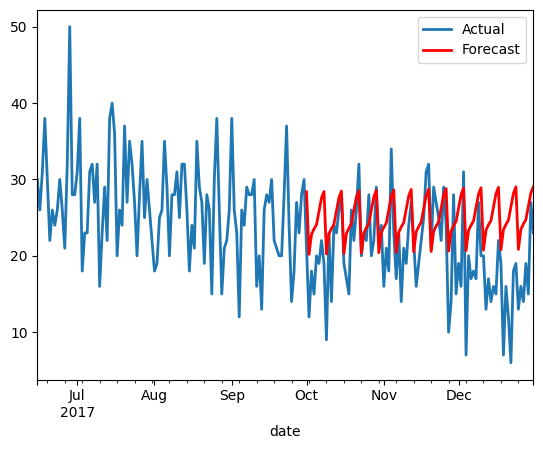

ПОМИЛКА: 39.00856138800186%


In [52]:
from darts.utils.utils import ModelMode, SeasonalityMode
exp_smooth = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE,
    seasonal=SeasonalityMode.ADDITIVE,
    seasonal_periods=7)
fit_and_plot(exp_smooth, series[-200:], train, val)

По якості виглядає десь на рівні з XGBoost хоча помилка суттєво вища

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


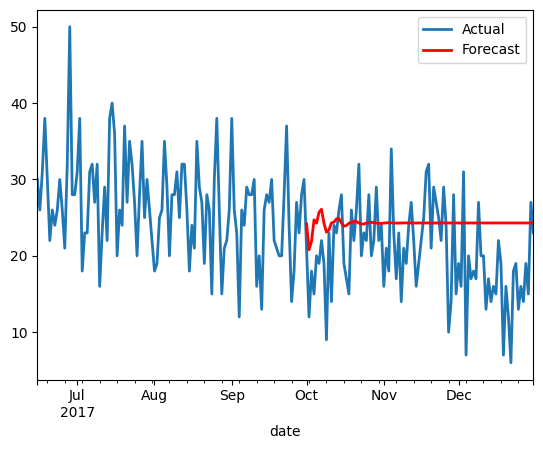

ПОМИЛКА: 39.52818300569095%


In [56]:
model_arima = ARIMA(p=7, d=1, q=1)
fit_and_plot(model_arima, series[-200:], train, val)

arima показує себе погано, після якогось періода предіктить константу

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=5, max_p=21, start_q=1, season_length=7)

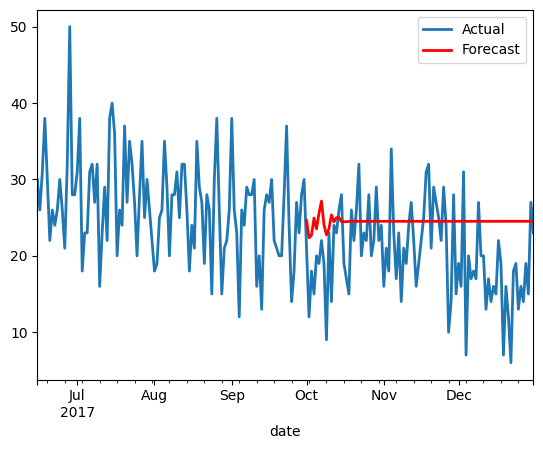

In [57]:
model = AutoARIMA(start_p=5, max_p=21, start_q=1, season_length=7) # спробуйте стартувати з інших значень і перегляньте, що виходить і додати потім також season_length=12
model.fit(train)

display(model)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
plot_results(series[-200:], forecast)


Нажаль якість взагалі не поліпшилась

14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [43]:
from darts.models import Prophet


prop_model = Prophet()
prop_model.fit(train)

# Прогнозування
forecast = prop_model.predict(len(val))

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


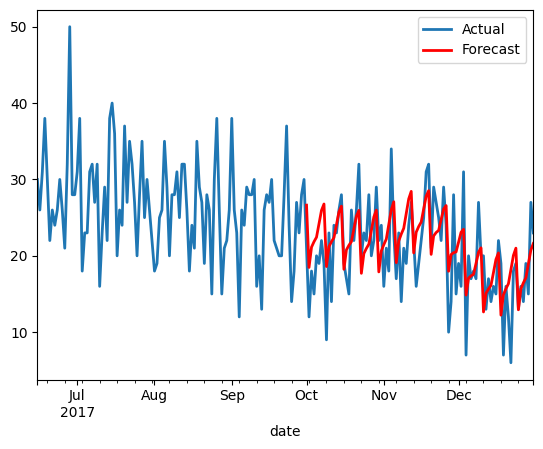

ПОМИЛКА: 23.804832095755977%


In [47]:
plot_results(series[-200:], forecast)
print(f'ПОМИЛКА: {mape(val, forecast)}%')

Prophet поки що показує найкращий результат, хоча візуально виглядає що модель наче запамятала певний патерн, що дещо бентежить

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [50]:
from darts.models import RNNModel
from darts.utils.timeseries_generation import datetime_attribute_timeseries

# Масштабування даних
transformer = Scaler()
train_transformed = transformer.fit_transform(train)
val_transformed = transformer.transform(val)
series_transformed = transformer.transform(series)

# Створити серії з атрибутом року і місяця
year_series = datetime_attribute_timeseries(
    pd.date_range(start=series.start_time(), freq=series.freq_str, periods=len(series)),
    attribute="year",
    one_hot=False,
)
year_series = Scaler().fit_transform(year_series)
month_series = datetime_attribute_timeseries(
    year_series, attribute="month", one_hot=True
)
covariates = year_series.stack(month_series)
cov_train, cov_val = covariates.split_before(pd.Timestamp("2017-12-01"))

# Побудова та тренування моделі LSTM
model = RNNModel(
    model="LSTM",
    input_chunk_length=14,
    hidden_dim=20,
    dropout=0,
    batch_size=16,
    n_epochs=100,
    optimizer_kwargs={"lr": 1e-3},
    log_tensorboard=True,
    random_state=42,
    training_length=20,
    force_reset=True,
)
model.fit(
    train_transformed,
    future_covariates=covariates,
    val_series=val_transformed,
    val_future_covariates=covariates,
    verbose=True)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  2.9 K │ train │     0 │
│ 6 │ V               │ Linear           │     21 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is 
set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


RNNModel(model=LSTM, hidden_dim=20, n_rnn_layers=1, dropout=0, training_length=20, input_chunk_length=14, batch_size=16, n_epochs=100, optimizer_kwargs={'lr': 0.001}, log_tensorboard=True, random_state=42, force_reset=True)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

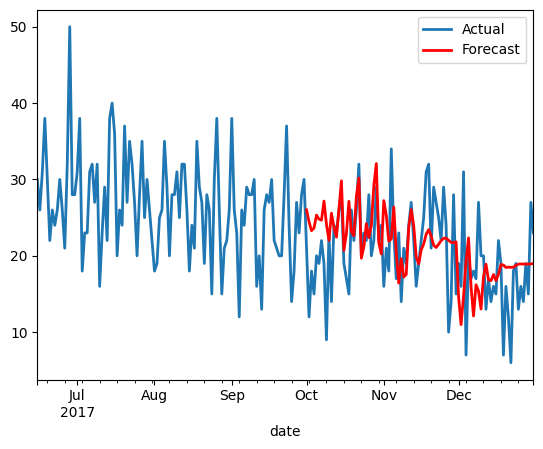

ПОМИЛКА: 29.927808425451566%


In [51]:
forecast = scaler.inverse_transform(model.predict(len(val)))

plot_results(series[-200:], forecast)
print(f'ПОМИЛКА: {mape(val, forecast)}%')

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [ ]:
вибачте, пропустив цей блок

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

якщо опиратись на візуальне порівняння валідаційних даних і прогнозу та помилки MAPE то кращим результат показує Prophet.
Загалом, хоч раніше дослідження на сезонність показала звязок із 7 днем, проте візуально видно що є і річна сезонність, мені здається це можна було б врахувати для покращення моделі